In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('ggplot')

In [2]:
df = pd.read_csv('yield_df.csv')

In [3]:
df.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [4]:
df.drop('Unnamed: 0',axis=1,inplace=True)

In [5]:
df.head()

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Area                           28242 non-null  object 
 1   Item                           28242 non-null  object 
 2   Year                           28242 non-null  int64  
 3   hg/ha_yield                    28242 non-null  int64  
 4   average_rain_fall_mm_per_year  28242 non-null  float64
 5   pesticides_tonnes              28242 non-null  float64
 6   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(2), object(2)
memory usage: 1.5+ MB


In [7]:
df.isnull().sum()

Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(2310)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.shape

(25932, 7)

In [12]:
df.describe()

,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,25932.000000,25932.000000,25932.000000,25932.000000,25932.000000
mean,2001.556455,76978.132925,1146.836688,34782.573241,20.422251
std,7.055924,84647.605552,717.391098,57228.568244,6.439402
min,1990.000000,50.000000,51.000000,0.040000,1.300000
25%,1995.000000,19996.000000,593.000000,1597.000000,16.580000
50%,2001.000000,39530.000000,1083.000000,15373.000000,21.420000
75%,2008.000000,104168.000000,1668.000000,45620.000000,26.060000
max,2013.000000,501412.000000,3240.000000,367778.000000,30.650000


In [13]:
df.drop(columns=['Area','Item'],inplace=False).corr()

,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
Year,1.000000,0.091327,-0.006423,0.135127,0.013701
hg/ha_yield,0.091327,1.000000,-0.004067,0.065523,-0.110400
average_rain_fall_mm_per_year,-0.006423,-0.004067,1.000000,0.161483,0.333694
pesticides_tonnes,0.135127,0.065523,0.161483,1.000000,0.045577
avg_temp,0.013701,-0.110400,0.333694,0.045577,1.000000


In [14]:
df.head()

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [15]:
len(df['Area'].unique())

101

In [16]:
len(df['Item'].unique())

10

C:\Users\krash\AppData\Local\Temp\ipykernel_12692\2653027358.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['Area'], palette=colors)


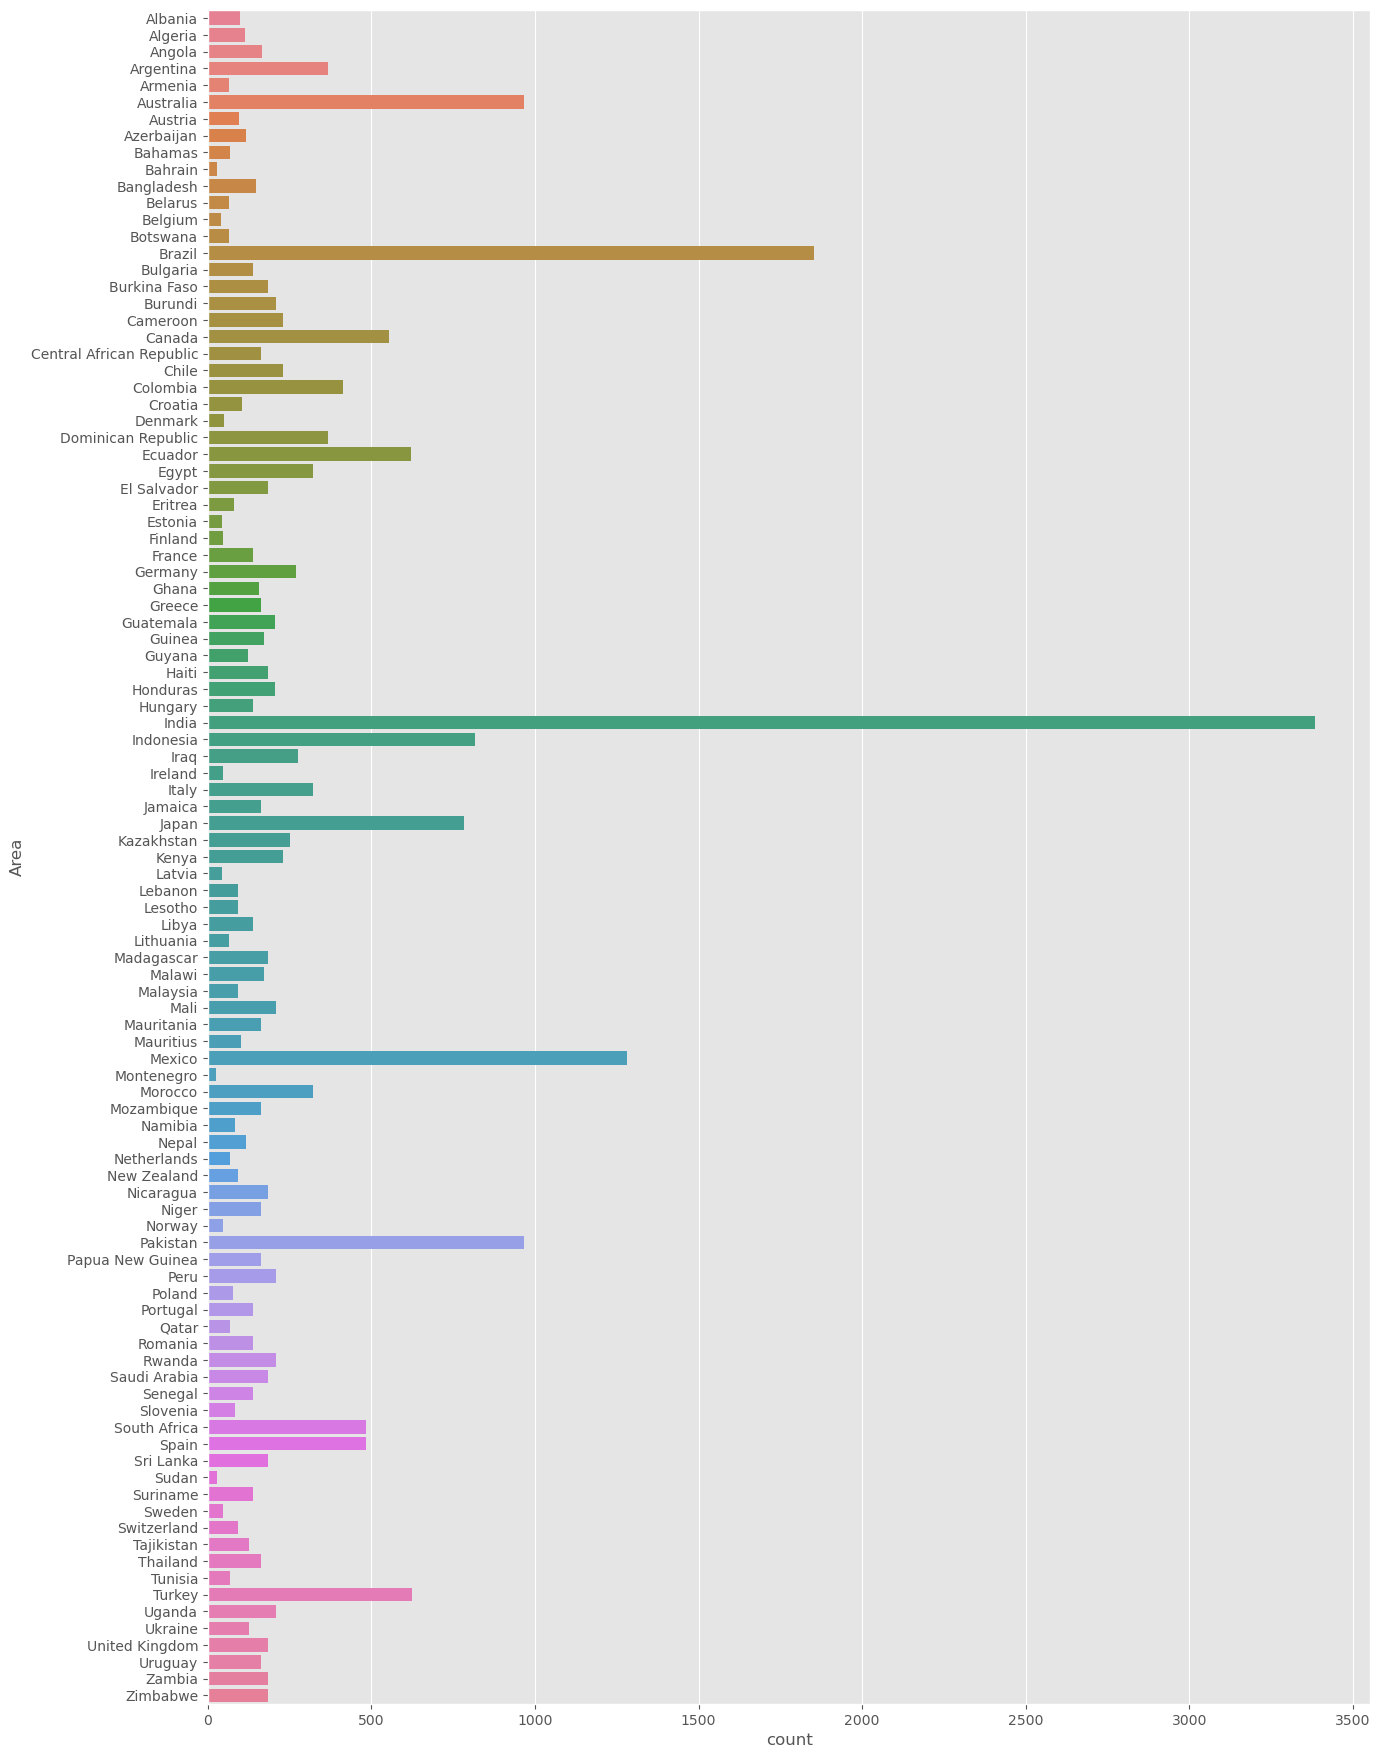

In [17]:
plt.figure(figsize=(15,22))

colors = sns.color_palette('husl', n_colors=len(df['Area'].unique()))
sns.countplot(y=df['Area'], palette=colors)
plt.show()

C:\Users\krash\AppData\Local\Temp\ipykernel_12692\2078688332.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['Item'], palette="tab10")


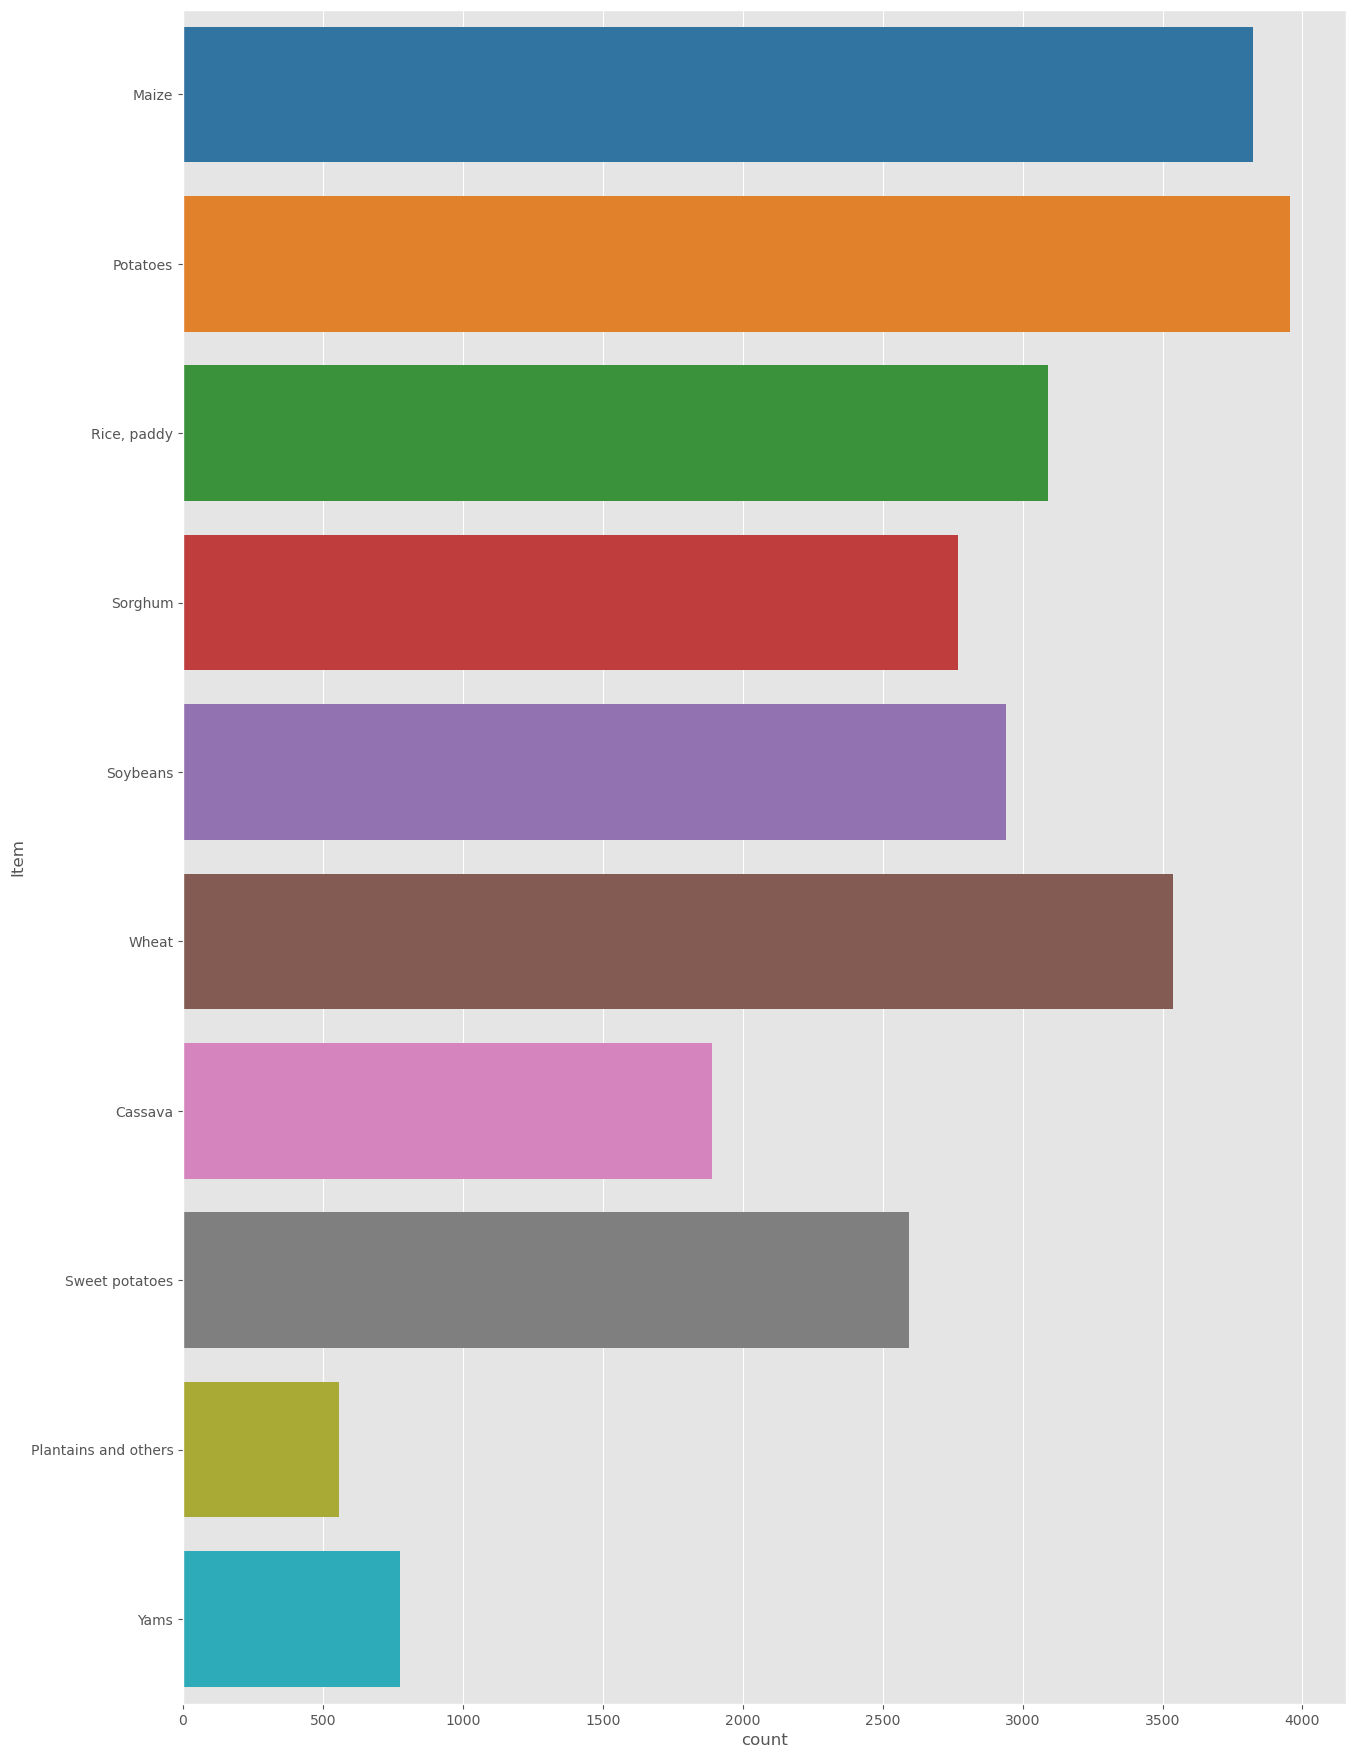

In [18]:
plt.figure(figsize=(15,22))

sns.countplot(y=df['Item'], palette="tab10")
plt.show()

In [19]:
(df['Area'].value_counts()<400).sum()

np.int64(88)

In [20]:
df[df['Area']=='India']['hg/ha_yield'].sum()

np.int64(274219558)

In [21]:
country = df['Area'].unique()
yield_per_country = []
for state in country:
    yield_per_country.append(df[df['Area']==state]['hg/ha_yield'].sum())

In [22]:
yield_per_country

[np.int64(5711536),
 np.int64(6711464),
 np.int64(5722563),
 np.int64(32864032),
 np.int64(4524100),
 np.int64(109111062),
 np.int64(10852258),
 np.int64(4608380),
 np.int64(4384717),
 np.int64(4443889),
 np.int64(7720159),
 np.int64(4704812),
 np.int64(8442270),
 np.int64(470651),
 np.int64(136340329),
 np.int64(6263075),
 np.int64(6083337),
 np.int64(7031146),
 np.int64(10717883),
 np.int64(34706922),
 np.int64(4255627),
 np.int64(20561214),
 np.int64(26927138),
 np.int64(6083167),
 np.int64(10701651),
 np.int64(25312166),
 np.int64(21315591),
 np.int64(36828848),
 np.int64(16855944),
 np.int64(1452416),
 np.int64(3595638),
 np.int64(6210668),
 np.int64(15790618),
 np.int64(38780463),
 np.int64(9260371),
 np.int64(14571925),
 np.int64(16508723),
 np.int64(7975743),
 np.int64(8361103),
 np.int64(8619194),
 np.int64(10920131),
 np.int64(8824110),
 np.int64(274219558),
 np.int64(68067328),
 np.int64(10984722),
 np.int64(9104030),
 np.int64(32280700),
 np.int64(19698007),
 np.int64(10092

C:\Users\krash\AppData\Local\Temp\ipykernel_12692\885792530.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=country,x=yield_per_country, palette=colors)


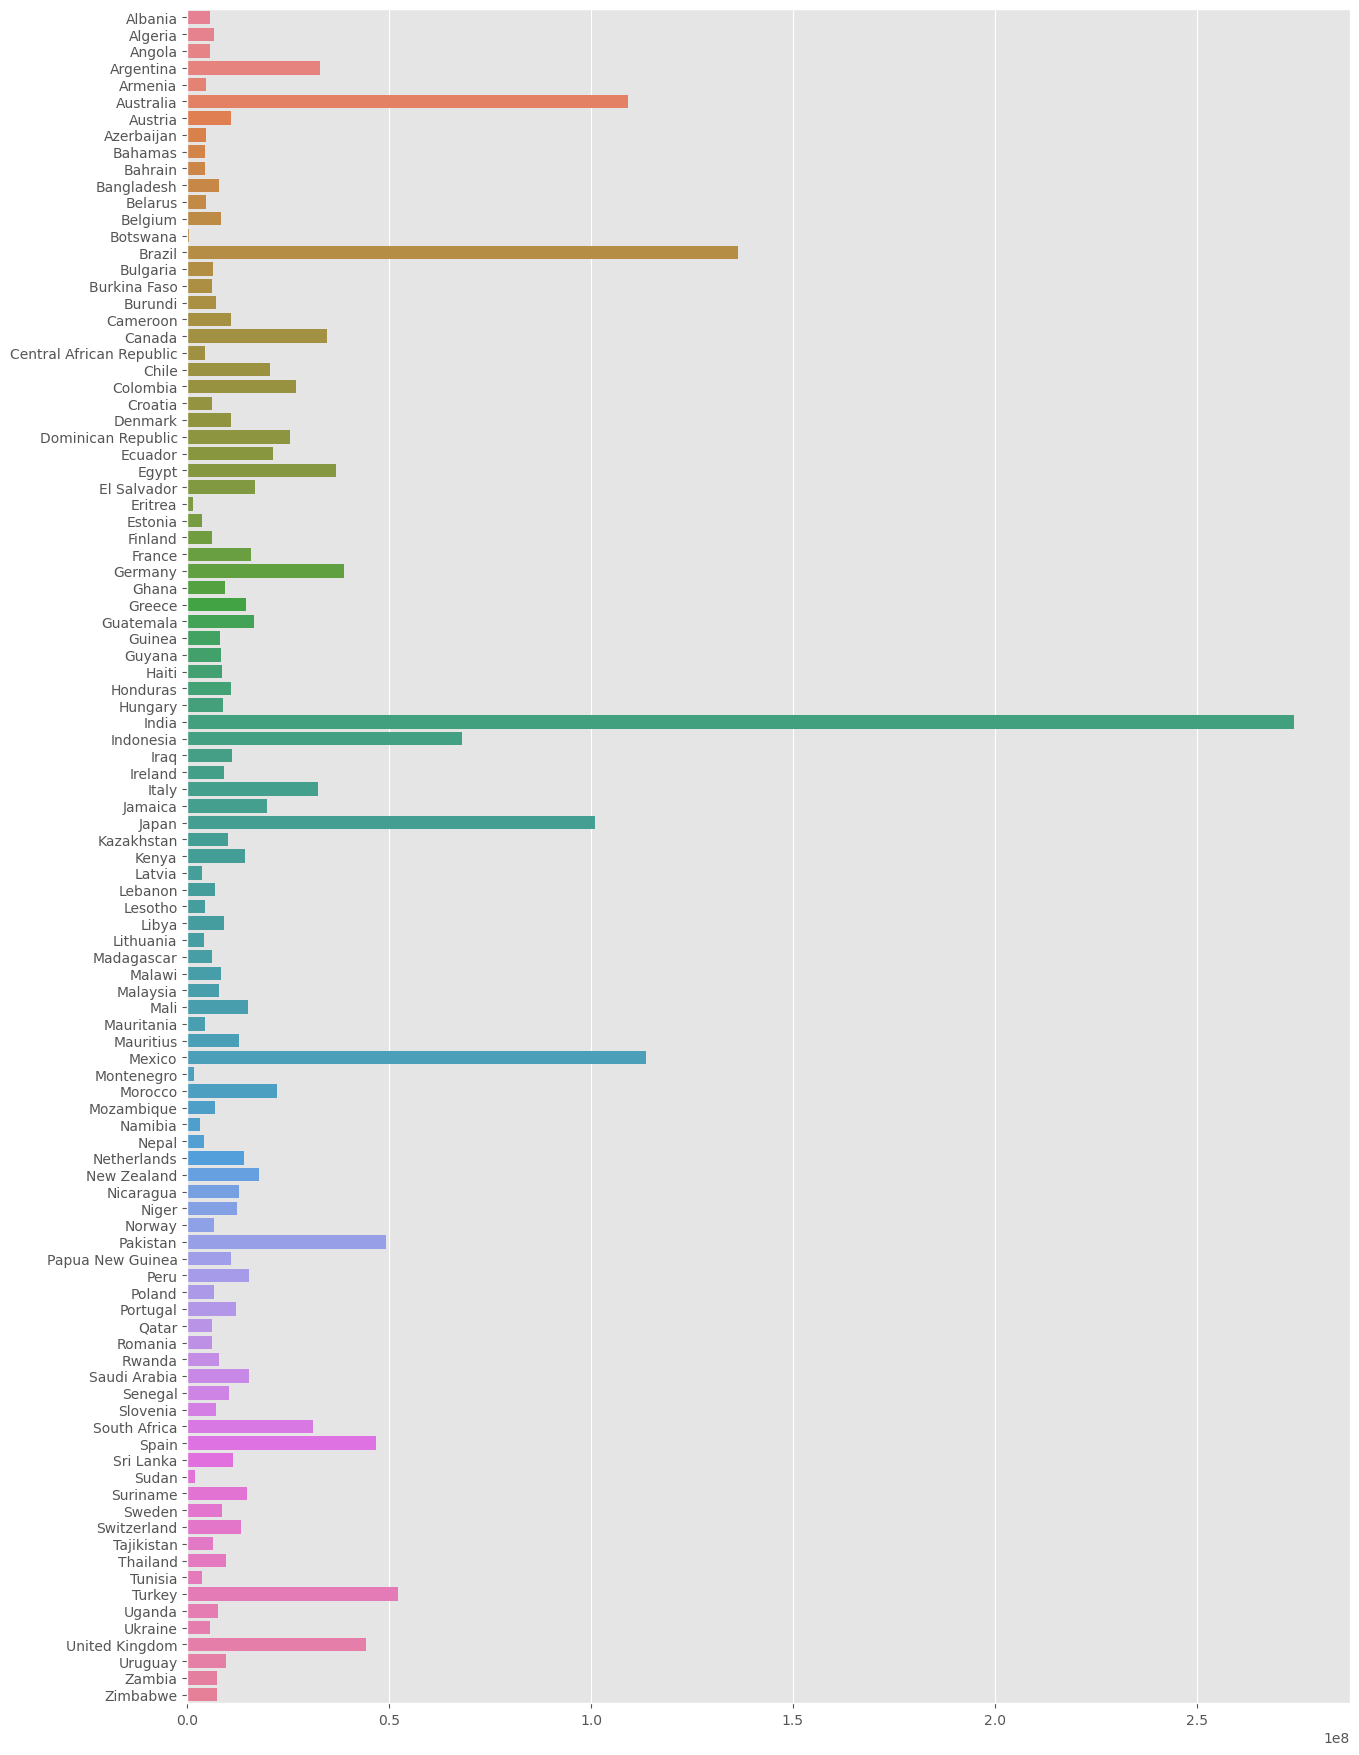

In [23]:
plt.figure(figsize=(15,22))

sns.barplot(y=country,x=yield_per_country, palette=colors)
plt.show()

In [24]:
df['Item'].value_counts()

Item
Potatoes                3956
Maize                   3824
Wheat                   3539
Rice, paddy             3091
Soybeans                2940
Sorghum                 2770
Sweet potatoes          2593
Cassava                 1889
Yams                     774
Plantains and others     556
Name: count, dtype: int64

In [25]:
crops = df['Item'].unique()
yield_per_crop = []
for crop in crops:
    yield_per_crop.append(df[df['Item']==crop]['hg/ha_yield'].sum())

In [26]:
yield_per_crop

[np.int64(142020761),
 np.int64(785921609),
 np.int64(127646024),
 np.int64(52906376),
 np.int64(49957039),
 np.int64(106614786),
 np.int64(275132269),
 np.int64(310269345),
 np.int64(58958974),
 np.int64(86769760)]

C:\Users\krash\AppData\Local\Temp\ipykernel_12692\611371820.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=crops,x=yield_per_crop, palette=colors)
C:\Users\krash\AppData\Local\Temp\ipykernel_12692\611371820.py:3: UserWarning: The palette list has more values (101) than needed (10), which may not be intended.
  sns.barplot(y=crops,x=yield_per_crop, palette=colors)


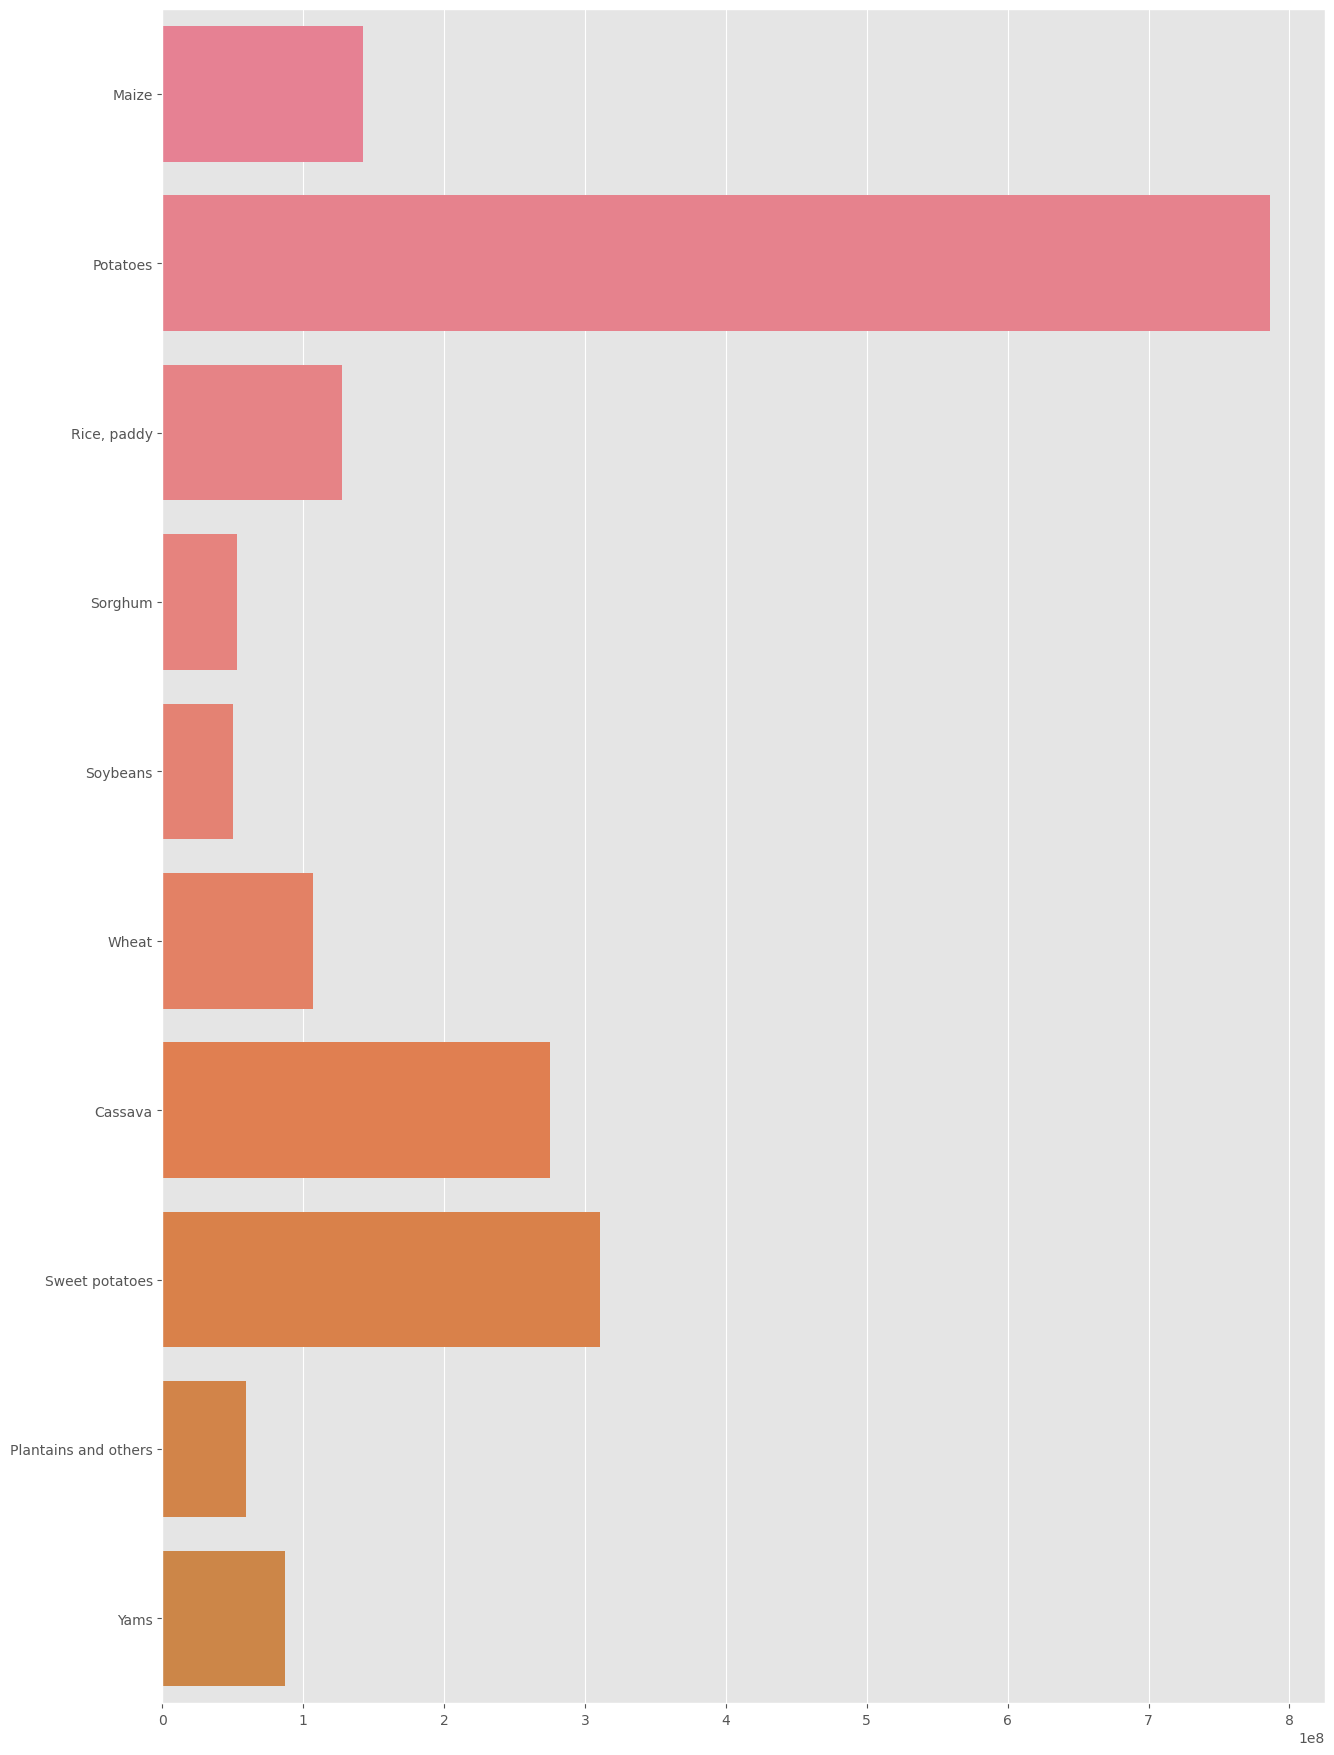

In [27]:
plt.figure(figsize=(15,22))

sns.barplot(y=crops,x=yield_per_crop, palette=colors)
plt.show()

In [28]:
df.head()

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [29]:
df.columns

Index(['Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year',
       'pesticides_tonnes', 'avg_temp'],
      dtype='object')

In [30]:
col = [ 'Year', 'average_rain_fall_mm_per_year',
       'pesticides_tonnes', 'avg_temp','Area', 'Item','hg/ha_yield']

In [31]:
df = df[col]

In [32]:
df[df['Area']=='India'].sample(10)

,Year,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,Area,Item,hg/ha_yield
11230,1994,1083.0,61357.00,26.03,India,Maize,14480
13901,2010,1083.0,40093.69,26.02,India,Potatoes,199299
11687,1996,1083.0,56114.00,27.01,India,Soybeans,10319
12224,1999,1083.0,46195.00,26.36,India,Sweet potatoes,85744
11255,1994,1083.0,61357.00,25.33,India,Potatoes,166101
13725,2009,1083.0,28707.01,25.99,India,Potatoes,188103
11663,1996,1083.0,56114.00,26.64,India,Sorghum,9591
13743,2009,1083.0,28707.01,27.15,India,"Rice, paddy",32366
12790,2004,1083.0,35113.00,26.11,India,Cassava,270436
10994,1992,1083.0,70791.00,27.24,India,Sweet potatoes,82835


In [33]:
x = df.drop(columns=['hg/ha_yield'])
y = df['hg/ha_yield']

In [34]:
x.shape,y.shape

((25932, 6), (25932,))

In [35]:
from sklearn.model_selection import train_test_split

In [36]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2 ,random_state=42)

In [37]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer([
    ('StandardScale',StandardScaler(),[0,1,2,3]),
    ('OneHotEncoding',OneHotEncoder(drop="first"),[4,5])
],remainder='passthrough')

In [38]:
x_train_dummy = preprocessor.fit_transform(x_train)
x_test_dummy = preprocessor.transform(x_test)

In [39]:
preprocessor.get_feature_names_out(col[:-1])

array(['StandardScale__Year',
       'StandardScale__average_rain_fall_mm_per_year',
       'StandardScale__pesticides_tonnes', 'StandardScale__avg_temp',
       'OneHotEncoding__Area_Algeria', 'OneHotEncoding__Area_Angola',
       'OneHotEncoding__Area_Argentina', 'OneHotEncoding__Area_Armenia',
       'OneHotEncoding__Area_Australia', 'OneHotEncoding__Area_Austria',
       'OneHotEncoding__Area_Azerbaijan', 'OneHotEncoding__Area_Bahamas',
       'OneHotEncoding__Area_Bahrain', 'OneHotEncoding__Area_Bangladesh',
       'OneHotEncoding__Area_Belarus', 'OneHotEncoding__Area_Belgium',
       'OneHotEncoding__Area_Botswana', 'OneHotEncoding__Area_Brazil',
       'OneHotEncoding__Area_Bulgaria',
       'OneHotEncoding__Area_Burkina Faso',
       'OneHotEncoding__Area_Burundi', 'OneHotEncoding__Area_Cameroon',
       'OneHotEncoding__Area_Canada',
       'OneHotEncoding__Area_Central African Republic',
       'OneHotEncoding__Area_Chile', 'OneHotEncoding__Area_Colombia',
       'OneHotEncod

In [40]:
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error,r2_score,accuracy_score

In [41]:
models = {
    'Linear Regression':LinearRegression(),
    'Lasso':Lasso(),
    'Ridge':Ridge(),
    'Decision Tree':DecisionTreeRegressor(),
    'KNN':KNeighborsRegressor()
}
for name,md in models.items():
    md.fit(x_train_dummy,y_train)
    y_pred = md.predict(x_test_dummy)
    print(f"{name} mae : {mean_absolute_error(y_test,y_pred)} score : {r2_score(y_test,y_pred)}")

Linear Regression mae : 29920.714691553152 score : 0.7486558611582361


C:\Users\krash\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 199884855870.7422, tolerance: 14819338848.544127
  model = cd_fast.sparse_enet_coordinate_descent(


Lasso mae : 29907.64138249029 score : 0.7485842409647616
Ridge mae : 29875.501364625612 score : 0.7485373513133267
Decision Tree mae : 4089.4854443801814 score : 0.9777278219704849
KNN mae : 4869.094042799306 score : 0.9823085267797652


In [42]:
dtr = DecisionTreeRegressor()
dtr.fit(x_train_dummy,y_train)
dtr.predict(x_test_dummy)

array([167489.,  15838.,  72614., ...,  52692.,   9621., 132600.])

In [43]:
df.columns

Index(['Year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes',
       'avg_temp', 'Area', 'Item', 'hg/ha_yield'],
      dtype='object')

In [ ]:
def prediction(Year,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,Area,Item):
    features = np.array([[Year,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,Area,Item]],dtype=object)
    transform_features = preprocessor.transform(features)
    predicted_yield = dtr.predict(transform_features).reshape(-1,1)
    return predicted_yield[0][0]

In [45]:
result = prediction(1990,1485.0,121.0,16.37,'Albania','Maize')

C:\Users\krash\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\krash\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


In [46]:
result

np.float64(36613.0)

In [47]:
import pickle
pickle.dump(dtr,open('dtr.pkl','wb'))
pickle.dump(preprocessor,open('preprocessor.pkl','wb'))